import pandas for read dataset frpm a file csv

In [31]:
import pandas as pd

in this i wight a function that read dataset form the given csv file 

In [32]:
df=pd.read_csv("IMDB Dataset.csv")
print(df.head(4))

                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative


from here we analysis the data  some mathodes we perform for  knowing datset  what is in it and what type of dat is this how many columns an size of data set and how many rows in the dataset 

In [33]:
df.columns


Index(['review', 'sentiment'], dtype='object')

In [34]:
df.shape

(50000, 2)

we just check here that given dataset is balanced or not(imbalanced )

In [35]:
print(df["sentiment"].unique())
print(df["sentiment"].value_counts())

['positive' 'negative']
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


dataset is balanced ✅✅

right here we just transform the sentiment coluns into intger form 

In [36]:
df["sentiment"]=df["sentiment"].map({'positive':1,'negative':0})

In [37]:
df["sentiment"].head(4)

0    1
1    1
2    1
3    0
Name: sentiment, dtype: int64

In [39]:
df.head(8)

,review,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1
5,"Probably my all-time favorite movie, a story o...",1
6,I sure would like to see a resurrection of a u...,1
7,"This show was an amazing, fresh & innovative i...",0


3️⃣ Text Preprocessing we stat from here preprocessing the data of batter understanding 

Typical cleaning steps:

1 remove HTML tags

2 lowercase

3 remove punctuation

4 remove stopwords

5 lemmatization

step 1 :- Remove HTML Tags

In [8]:
import re# in this w use rgexfor removing htl tags

def remove_html_tags(text):
    clean = re.sub(r'<.*?>', '', text)
    return clean

In [9]:
review_clean = df["review"].apply(remove_html_tags)


print(review_clean)

0        One of the other reviewers has mentioned that ...
1        A wonderful little production. The filming tec...
2        I thought this was a wonderful way to spend ti...
3        Basically there's a family where a little boy ...
4        Petter Mattei's "Love in the Time of Money" is...
                               ...                        
49995    I thought this movie did a down right good job...
49996    Bad plot, bad dialogue, bad acting, idiotic di...
49997    I am a Catholic taught in parochial elementary...
49998    I'm going to have to disagree with the previou...
49999    No one expects the Star Trek movies to be high...
Name: review, Length: 50000, dtype: object


In this you can seee above that all html tags remove sucessfully  ✅✅✅

Step 2:-convert to Lowecase

In [10]:

def to_lowercase(text):
    
    if isinstance(text, str):
        text = text.lower()
    
    return text

In [11]:
low_con=review_clean.apply(to_lowercase)
print(low_con)

0        one of the other reviewers has mentioned that ...
1        a wonderful little production. the filming tec...
2        i thought this was a wonderful way to spend ti...
3        basically there's a family where a little boy ...
4        petter mattei's "love in the time of money" is...
                               ...                        
49995    i thought this movie did a down right good job...
49996    bad plot, bad dialogue, bad acting, idiotic di...
49997    i am a catholic taught in parochial elementary...
49998    i'm going to have to disagree with the previou...
49999    no one expects the star trek movies to be high...
Name: review, Length: 50000, dtype: object


✅✅ we sucessfully convert uppercase latter into lowercase latters 

Step 3:- Remove Punchautions

In [12]:

def remove_punctuation(text):
    
    punctuation = r"[~!@#$%^&*\-?;:\"'+=_`>,<./(){}\[\]|]"
    
    if isinstance(text, str):
        text = re.sub(punctuation, "", text)
    
    return text

In [13]:
re_pun=low_con.apply(remove_punctuation)
df=re_pun
print(df)

0        one of the other reviewers has mentioned that ...
1        a wonderful little production the filming tech...
2        i thought this was a wonderful way to spend ti...
3        basically theres a family where a little boy j...
4        petter matteis love in the time of money is a ...
                               ...                        
49995    i thought this movie did a down right good job...
49996    bad plot bad dialogue bad acting idiotic direc...
49997    i am a catholic taught in parochial elementary...
49998    im going to have to disagree with the previous...
49999    no one expects the star trek movies to be high...
Name: review, Length: 50000, dtype: object


✅✅ so here we sucessfullyremove punchuations from the given dataset

Step 4:- Remove stopwords

In [14]:
import nltk
nltk.download("stopwords")
nltk.download("punkt")


nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to C:\Users\Dell
[nltk_data]     5490T\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to C:\Users\Dell
[nltk_data]     5490T\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Dell
[nltk_data]     5490T\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\Dell
[nltk_data]     5490T\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [15]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words("english"))

def remove_stopwords(text):
    tokens = word_tokenize(text)
    filtered_words = [w for w in tokens if w.lower() not in stop_words]
    return " ".join(filtered_words)

In [16]:
new_dd=df.apply(remove_stopwords)
print(new_dd)

0        one reviewers mentioned watching 1 oz episode ...
1        wonderful little production filming technique ...
2        thought wonderful way spend time hot summer we...
3        basically theres family little boy jake thinks...
4        petter matteis love time money visually stunni...
                               ...                        
49995    thought movie right good job wasnt creative or...
49996    bad plot bad dialogue bad acting idiotic direc...
49997    catholic taught parochial elementary schools n...
49998    im going disagree previous comment side maltin...
49999    one expects star trek movies high art fans exp...
Name: review, Length: 50000, dtype: object


In [17]:
def tokenize_text(text):
    if isinstance(text, str):
        return word_tokenize(text)
    return text

In [18]:
new_d=new_dd.apply(tokenize_text)
print(new_d)

0        [one, reviewers, mentioned, watching, 1, oz, e...
1        [wonderful, little, production, filming, techn...
2        [thought, wonderful, way, spend, time, hot, su...
3        [basically, theres, family, little, boy, jake,...
4        [petter, matteis, love, time, money, visually,...
                               ...                        
49995    [thought, movie, right, good, job, wasnt, crea...
49996    [bad, plot, bad, dialogue, bad, acting, idioti...
49997    [catholic, taught, parochial, elementary, scho...
49998    [im, going, disagree, previous, comment, side,...
49999    [one, expects, star, trek, movies, high, art, ...
Name: review, Length: 50000, dtype: object


✅✅ we have sucessfully remove stop words from the data and one more techniquice we use tokenization 

step 5:- lemmatization

In [19]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()
def lemmatize_words(tokens):
    
    if isinstance(tokens, list):
        return [lemmatizer.lemmatize(word) for word in tokens]
    
    return tokens

In [20]:
lemin=new_d.apply(lemmatize_words)


In [21]:
print(lemin)

0        [one, reviewer, mentioned, watching, 1, oz, ep...
1        [wonderful, little, production, filming, techn...
2        [thought, wonderful, way, spend, time, hot, su...
3        [basically, there, family, little, boy, jake, ...
4        [petter, matteis, love, time, money, visually,...
                               ...                        
49995    [thought, movie, right, good, job, wasnt, crea...
49996    [bad, plot, bad, dialogue, bad, acting, idioti...
49997    [catholic, taught, parochial, elementary, scho...
49998    [im, going, disagree, previous, comment, side,...
49999    [one, expects, star, trek, movie, high, art, f...
Name: review, Length: 50000, dtype: object


✅✅ we successfully done lemmmite

NOw we perfrom TF IDF techniquenic into he given dataset

In [22]:
print(type(lemin))
print(lemin[:2])

<class 'pandas.core.series.Series'>
0    [one, reviewer, mentioned, watching, 1, oz, ep...
1    [wonderful, little, production, filming, techn...
Name: review, dtype: object


n this a very big mistake we have to join the give data  by using lamda 

In [23]:
lemin = lemin.apply(lambda x: " ".join(x))

In [24]:
print(lemin)

0        one reviewer mentioned watching 1 oz episode y...
1        wonderful little production filming technique ...
2        thought wonderful way spend time hot summer we...
3        basically there family little boy jake think t...
4        petter matteis love time money visually stunni...
                               ...                        
49995    thought movie right good job wasnt creative or...
49996    bad plot bad dialogue bad acting idiotic direc...
49997    catholic taught parochial elementary school nu...
49998    im going disagree previous comment side maltin...
49999    one expects star trek movie high art fan expec...
Name: review, Length: 50000, dtype: object


In [48]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(  max_features=5000,
    ngram_range=(1,2))

X_ray= tfidf.fit_transform(lemin).toarray()

print(X_ray)

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [49]:
y = df['sentiment']
X=X_ray

now we done tf-IDF 

Step 6:- Train and test splits

In [50]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

here we use ml model logistic regression and train themodel 

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

We Predict the data 

In [60]:
pred = model.predict(X_test)

Accuracy check 

In [61]:
from sklearn.metrics import accuracy_score

print(accuracy_score(y_test,pred))

0.8842


here we comppletly check accurasy and train the model form the given dataset

know we check take a review from the user and predict the reiew

In [55]:
review = ["This movie is fantastic"]

vector = tfidf.transform(review)

prediction = model.predict(vector)

print(prediction)

[1]


in this project we exicute many nlp mathods and techniqus so this  is a berief intro of what tasks we perfrom 

Dataset
 ↓
 
Remove HTML tags
 ↓
 
Lowercase
 ↓
 
Remove punctuation
 ↓
 
Stopwords removal
 ↓
 
Lemmatization
 ↓
 
TF-IDF
 ↓
 
Machine Learning Model
 ↓
 
Prediction

In [56]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred)

print(cm)

[[4338  623]
 [ 483 4556]]


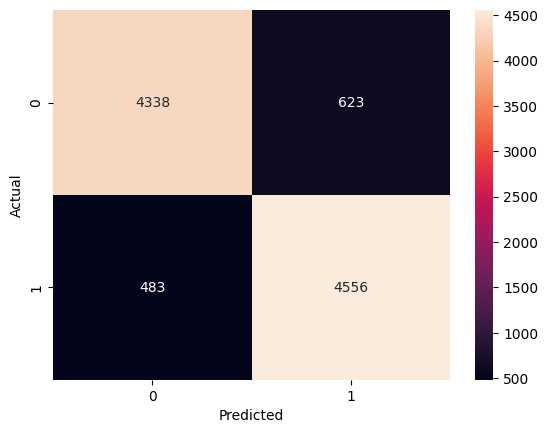

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt="d")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [58]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.90      0.87      0.89      4961
           1       0.88      0.90      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000

